In [34]:
import numpy as np 
import matplotlib.pyplot as plt

In [35]:
n = 1000
Z = np.random.normal(0, 1, n)

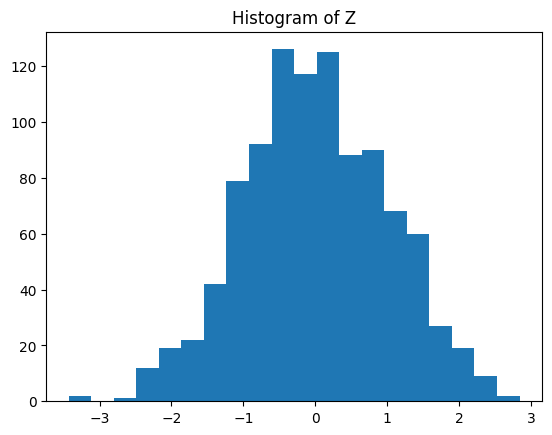

In [36]:
plt.hist(Z, bins=20)
plt.title("Histogram of Z")
plt.show()

In [37]:
split_1, split_2 = np.split(Z, 2)
Y_train, Y_calib = split_1, split_2
X_train = np.linspace(-3, 3, len(Y_train))
X_calib = np.linspace(-3, 3, len(Y_calib))

In [38]:
from sklearn import linear_model

model = linear_model.LinearRegression()
model.fit(X_train.reshape(-1, 1), Y_train)  

LinearRegression()

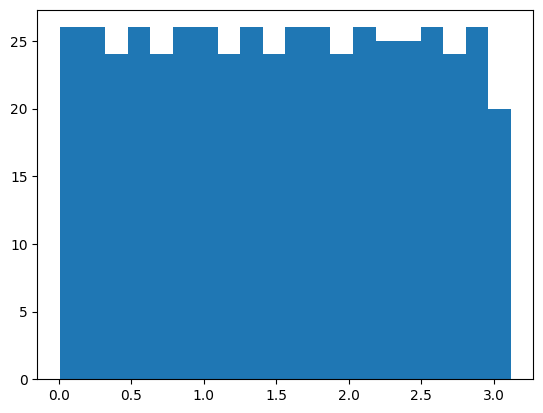

In [39]:
preds = model.predict(X_calib.reshape(-1, 1))
scores = np.abs(preds - X_calib)

plt.hist(scores, bins=20)
plt.show()

In [40]:
scores_sorted = list(np.sort(scores))
alpha = 0.1
n_calib = len(X_calib)
r = int(np.ceil((1 - alpha) * (n_calib + 1))) - 1

S_r = scores_sorted[r]
S_r

2.785561157416132

In [41]:
def C_r(x, model, S_r):
    pred = model.predict(np.array([[x]]))
    return [pred - S_r, pred + S_r]

x_test = 0.5
C_r(x_test, model, S_r)

[array([-2.76292388]), array([2.80819843])]

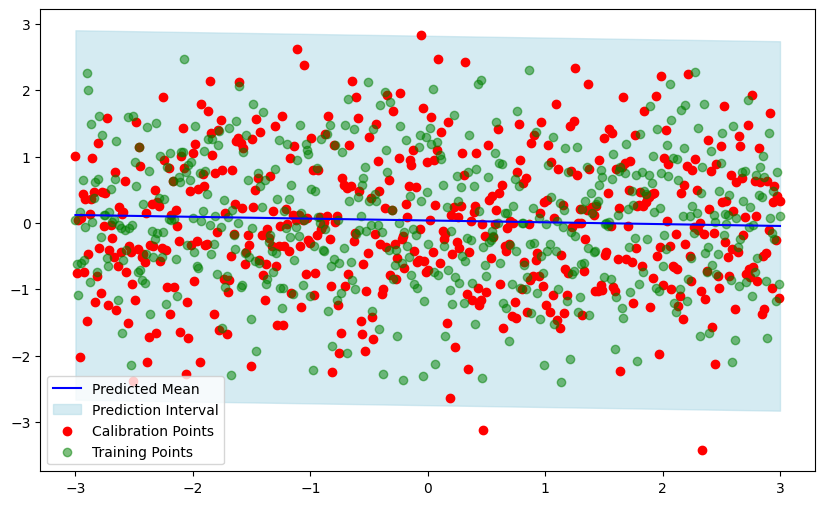

In [44]:
# plotting the prediction interval

x_range = np.linspace(-3, 3, 100)
preds_range = model.predict(x_range.reshape(-1, 1))
lower_bound = preds_range - S_r
upper_bound = preds_range + S_r
plt.figure(figsize=(10, 6))
plt.plot(x_range, preds_range, label='Predicted Mean', color='blue')
plt.fill_between(x_range, lower_bound, upper_bound, color='lightblue', alpha=0.5, label='Prediction Interval')
plt.scatter(X_calib, Y_calib, color='red', label='Calibration Points')
plt.scatter(X_train, Y_train, color='green', label='Training Points', alpha=0.5)
plt.legend()
plt.show()